# Chapter 7. Asymptotic Theory of Statistical Inference

Source orientation: printed pages 165-177, PDF pages 173-185 of *Information Geometry and Its Applications*.

This notebook is a standalone computational reading of the chapter. The guiding question is: when data become a small cloud around the true distribution, what geometric features decide whether an estimator uses that cloud as efficiently as possible?

The visual thread has five stops:

1. The maximum likelihood estimate in an exponential family is the observed sufficient statistic, seen as a projection in expectation coordinates.
2. A curved exponential family is a submanifold inside a larger flat family, so the observed point usually misses the model and must be mapped back.
3. Every consistent estimator determines ancillary fibers, the sets of ambient observations that map to the same estimate.
4. First-order Fisher efficiency is the special case where those fibers meet the model orthogonally.
5. Higher-order asymptotics compares bias-corrected efficient estimators through model curvature, coordinate curvature, and ancillary-fiber curvature; testing reuses the same boundary geometry.

No source text is copied here. The formulas are used as orientation for fresh prose, code, and visual checks.


## Setup

Generated files are stored below `artifacts/chapter-07/`. The setup cell discovers the course root from wherever the notebook is executed, then keeps all paths book-local.


In [1]:
from pathlib import Path
import json
import math
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
import plotly.graph_objects as go
from IPython.display import display, Image, HTML, Markdown


def find_book_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    for candidate in [start, *start.parents]:
        if (candidate / 'AGENTS.md').exists() and (candidate / 'artifacts').exists():
            return candidate
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if candidate.name == 'Information-Geometry-and-Its-Applications':
            return candidate
    raise RuntimeError('Could not locate Information-Geometry-and-Its-Applications root')

BOOK_ROOT = find_book_root()
os.chdir(BOOK_ROOT)
ARTIFACT_DIR = Path('artifacts/chapter-07')
FIG_DIR = ARTIFACT_DIR / 'figures'
HTML_DIR = ARTIFACT_DIR / 'html'
TABLE_DIR = ARTIFACT_DIR / 'tables'
CHECK_DIR = ARTIFACT_DIR / 'checks'
for folder in [FIG_DIR, HTML_DIR, TABLE_DIR, CHECK_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

rng = np.random.default_rng(20260501)
plt.rcParams.update({
    'figure.dpi': 130,
    'savefig.dpi': 180,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.22,
})


def savefig(path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    plt.tight_layout()
    plt.savefig(path, bbox_inches='tight')
    plt.close()
    return path


def display_artifact(path, kind=None):
    path = Path(path)
    rel = path.as_posix()
    if kind == 'html' or path.suffix.lower() == '.html':
        display(HTML(f'<a href="{rel}" target="_blank">Open interactive artifact: {path.name}</a>'))
    elif path.suffix.lower() in {'.png', '.jpg', '.jpeg'}:
        display(Image(filename=str(path)))
    elif path.suffix.lower() == '.csv':
        display(pd.read_csv(path))
    elif path.suffix.lower() == '.json':
        display(Markdown(f'`{rel}`'))
    else:
        display(Markdown(f'`{rel}`'))


## 1. Translation Guide: Asymptotics as Local Geometry

A parametric model is a surface of probability distributions. An estimator reads a sample and returns a point on that surface. For large sample size `N`, the observed sufficient statistic fluctuates at scale `1/sqrt(N)`, so the model can be studied through its tangent space plus the first few curvature corrections.

The chapter uses several coordinate systems at once:

| Statistical phrase | Geometric translation | Computational handle |
| --- | --- | --- |
| observed sufficient statistic | random point in the ambient exponential family | sample mean in expectation coordinates |
| MLE in a full exponential family | the observed point itself | solve `eta(theta) = xbar` |
| curved exponential family | submanifold `S` embedded in a flat family `M` | a curve or surface `eta(u)` inside ambient coordinates |
| estimator on a curved family | map from ambient observations back to `S` | projection or fiber coordinate `u_hat = f(eta_bar)` |
| ancillary family | fibers of equal estimate | curves/surfaces crossing `S` |
| Fisher efficiency | first-order covariance reaches the Cramer-Rao lower bound | fibers orthogonal to `S` in Fisher metric |
| bias correction | remove the order `1/N` drift before comparing efficient estimators | subtract an estimated local bias field |
| second-order efficiency | compare the next covariance term | separate model curvature, coordinate curvature, and ancillary-fiber curvature |
| hypothesis testing | rejection boundaries near a null point | moving boundary hypersurfaces that behave like ancillary fibers |
| non-regular models | Fisher metric can degenerate or diverge | later chapters need singular or Finsler-like geometry |

The code below starts with a full exponential family, then intentionally bends the model so that projection, ancillary fibers, bias correction, and higher-order comparison become visible.


In [2]:
translation_rows = [
    {'chapter object': 'full exponential family', 'local picture': 'flat ambient manifold', 'estimation rule': 'match expectation coordinates to the observed sufficient statistic'},
    {'chapter object': 'curved exponential family', 'local picture': 'submanifold S inside M', 'estimation rule': 'map the observed ambient point back to S'},
    {'chapter object': 'ancillary fiber A(u)', 'local picture': 'all observations assigned the same u', 'estimation rule': 'read the u-coordinate of the crossing fiber'},
    {'chapter object': 'efficient estimator', 'local picture': 'fiber orthogonal to S', 'estimation rule': 'remove all first-order noise normal to S'},
    {'chapter object': 'Schur-complement covariance', 'local picture': 'eliminate fiber coordinates from the local metric', 'estimation rule': 'compute first-order variance from gbar_uu'},
    {'chapter object': 'bias-corrected estimator', 'local picture': 'order 1/N drift removed before comparison', 'estimation rule': 'compare covariance after local bias subtraction'},
    {'chapter object': 'higher-order comparison', 'local picture': 'three nonnegative curvature contributions', 'estimation rule': 'separate model, coordinate, and ancillary-fiber effects'},
    {'chapter object': 'hypothesis test', 'local picture': 'moving rejection boundary near the null point', 'estimation rule': 'analyze boundary angle and curvature as a testing analogue of fibers'},
]
translation_table = pd.DataFrame(translation_rows)
translation_path = TABLE_DIR / 'asymptotic_geometry_translation.csv'
translation_table.to_csv(translation_path, index=False)
display_artifact(translation_path)

storyboard = {
    'chapter_goal': 'Make large-sample inference visible as local geometry: shrinking estimator clouds, curved-family projection, ancillary foliations, first-order efficiency, second-order curvature terms, and hypothesis-test boundaries.',
    'source_span_read': {
        'printed_pages': '165-177',
        'pdf_pages': '173-185',
        'source_pdf': 'Information-Geometry-and-Its-Applications/Information Geometry and Its Applications.pdf',
        'used_for': 'orientation on section order, terminology, formulas, theorem roles, and concept boundaries only',
    },
    'coverage_refresh': [
        'estimation error, bias, consistency, Cramer-Rao bound, MLE first-order efficiency',
        'exponential-family observed point and expectation-coordinate MLE',
        'curved exponential family as a submanifold of an ambient exponential family',
        'ancillary fibers, local (u, v) coordinates, and orthogonality as first-order efficiency',
        'normalized errors, Jacobian blocks, and Schur-complement first-order covariance',
        'bias correction and second-order covariance contributions from model, coordinate, and ancillary curvature',
        'hypothesis-test rejection boundaries as N-dependent ancillary hypersurfaces',
        'chapter remarks on Bayes estimators, third-order MLE limits, local exponential families, singular models, and non-regular Finsler-like behavior',
    ],
    'visual_sequence': [
        {'artifact': 'figures/mle_observed_point_cloud.png', 'inspection_target': 'sample clouds contract at the inverse Fisher rate', 'validation': 'ellipse scale follows 1/sqrt(N)'},
        {'artifact': 'figures/curved_family_mle_projection.png', 'inspection_target': 'ambient observed point projects back to curved S', 'validation': 'projection residual is nearly orthogonal to tangent'},
        {'artifact': 'figures/ancillary_fiber_foliations.png', 'inspection_target': 'orthogonal and tilted fibers encode different estimators', 'validation': 'tilted fibers inflate first-order variance'},
        {'artifact': 'figures/fisher_efficiency_angle_inflation.png', 'inspection_target': 'first-order variance penalty as fibers tilt away from orthogonality', 'validation': 'orthogonal fiber reaches the Cramer-Rao factor'},
        {'artifact': 'figures/first_order_schur_covariance_check.png', 'inspection_target': 'Section 7.4 covariance from normalized errors in (u, v) coordinates', 'validation': 'Schur-complement covariance matches inverse metric and simulation'},
        {'artifact': 'html/ancillary_fiber_coordinate_sheet.html', 'inspection_target': 'local (u, v) sheet around S', 'validation': 'same curve and fiber geometry as static plots'},
        {'artifact': 'figures/curved_family_curvature_diagnostic.png', 'inspection_target': 'where the curved model departs from its tangent approximation', 'validation': 'curvature is nonnegative and sampled along S'},
        {'artifact': 'figures/second_order_covariance_decomposition.png', 'inspection_target': 'bias-corrected second-order covariance terms', 'validation': 'terms are nonnegative and MLE ancillary term is zero in the toy decomposition'},
        {'artifact': 'figures/applied_lab_variance_scaling.png', 'inspection_target': 'orthogonal and tilted estimators under simulation', 'validation': 'variance decreases with N and tilted estimator remains worse'},
        {'artifact': 'figures/hypothesis_testing_boundaries.png', 'inspection_target': 'testing boundaries approach the null and behave like ancillary hypersurfaces', 'validation': 'boundary distances shrink as N grows'},
        {'artifact': 'tables/named_test_boundary_geometry.csv', 'inspection_target': 'Rao, Wald, likelihood-ratio, and locally most powerful tests share first-order geometry but differ beyond it', 'validation': 'named-test table includes all four source-named tests'},
    ],
    'library_routing': [
        {'concept': 'first-order estimator clouds and ellipses', 'library': 'NumPy + Matplotlib', 'why': 'closed-form covariance makes the geometry inspectable'},
        {'concept': 'curved exponential family and projections', 'library': 'NumPy + Matplotlib', 'why': 'a planar embedded curve exposes tangent, normal, and residual checks'},
        {'concept': 'normalized-error and Schur-complement checks', 'library': 'NumPy + Pandas + Matplotlib', 'why': 'the local metric block calculation is small enough to compute directly'},
        {'concept': 'local coordinate sheet', 'library': 'Plotly', 'why': '3D rotation makes the (u, v) foliation easier to inspect'},
        {'concept': 'second-order term ledger', 'library': 'Pandas + Matplotlib', 'why': 'the theorem is a nonnegative contribution decomposition, naturally shown as a table and stacked bars'},
    ],
}
storyboard_path = CHECK_DIR / 'chapter-07-visual-storyboard.json'
storyboard_path.write_text(json.dumps(storyboard, indent=2), encoding='utf-8')
display_artifact(storyboard_path)


,chapter object,local picture,estimation rule
0,full exponential family,flat ambient manifold,match expectation coordinates to the observed ...
1,curved exponential family,submanifold S inside M,map the observed ambient point back to S
2,ancillary fiber A(u),all observations assigned the same u,read the u-coordinate of the crossing fiber
3,efficient estimator,fiber orthogonal to S,remove all first-order noise normal to S
4,Schur-complement covariance,eliminate fiber coordinates from the local metric,compute first-order variance from gbar_uu
5,bias-corrected estimator,order 1/N drift removed before comparison,compare covariance after local bias subtraction
6,higher-order comparison,three nonnegative curvature contributions,"separate model, coordinate, and ancillary-fibe..."
7,hypothesis test,moving rejection boundary near the null point,analyze boundary angle and curvature as a test...


`artifacts/chapter-07/checks/chapter-07-visual-storyboard.json`

## 2. Full Exponential Family: The MLE Is the Observed Point

In a full exponential family, the sample mean of the sufficient statistic is an expectation-coordinate point. If the true expectation coordinate is `eta`, the observed point `eta_bar` has covariance approximately `G^{-1}/N`. The MLE is obtained by matching the model expectation to this observed point, so in `eta`-coordinates there is no geometric detour: the estimator is just the observed point.

The next figure uses a two-dimensional sufficient statistic. The ellipse shrinks like `1/sqrt(N)`, which is the visual form of the first-order Cramer-Rao rate.


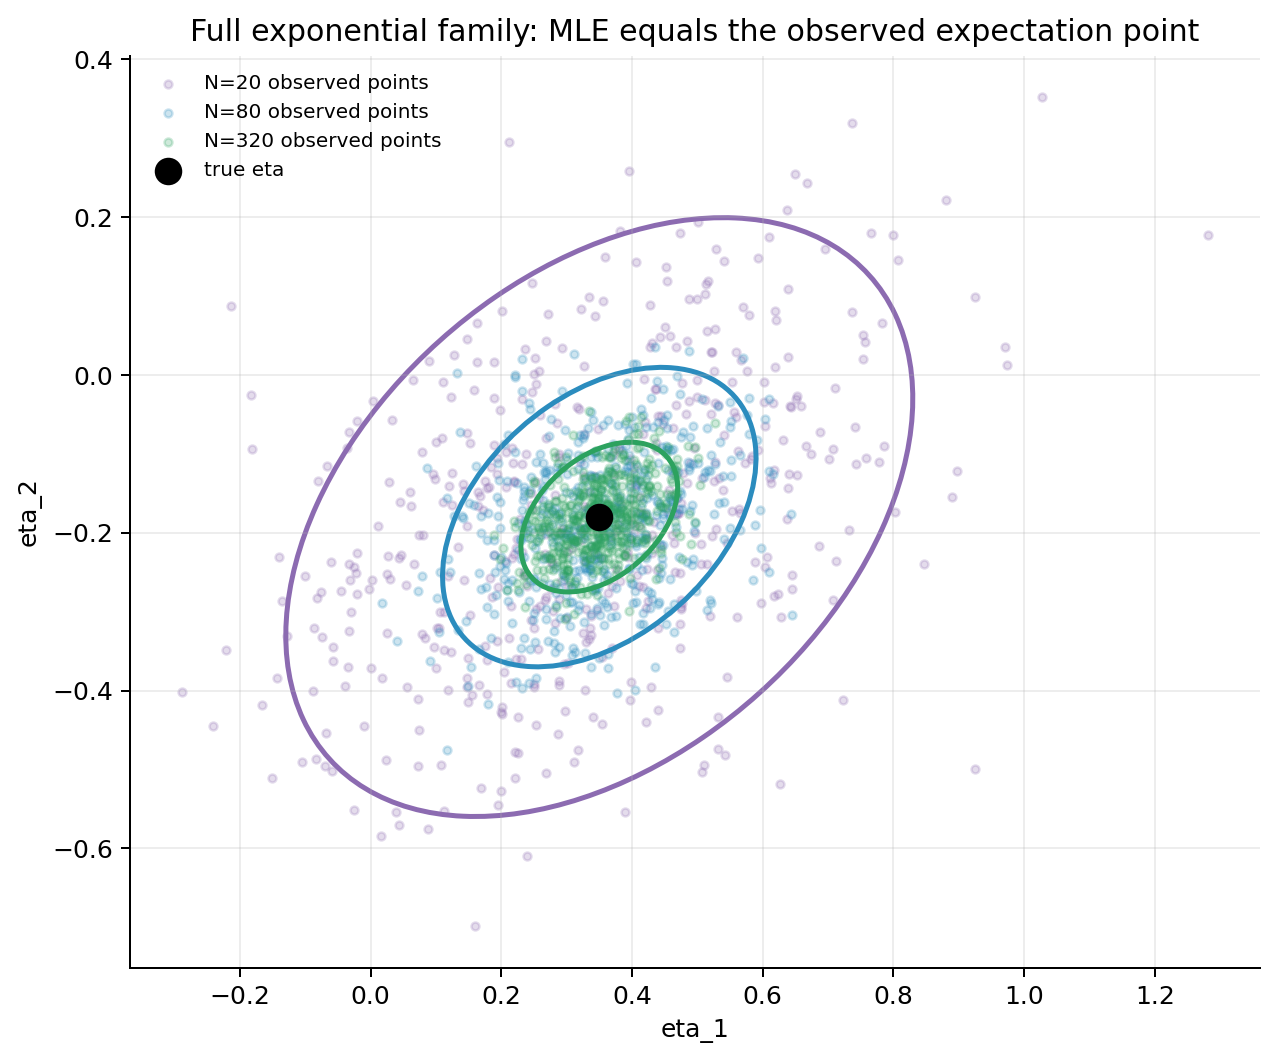

In [3]:
eta_true = np.array([0.35, -0.18])
G_inv = np.array([[1.15, 0.36], [0.36, 0.72]])
Ns = [20, 80, 320]
colors = ['#8c6bb1', '#2b8cbe', '#2ca25f']
fig, ax = plt.subplots(figsize=(7.2, 6.0))
for N, color in zip(Ns, colors):
    samples = rng.multivariate_normal(eta_true, G_inv / N, size=500)
    ax.scatter(samples[:, 0], samples[:, 1], s=10, alpha=0.23, color=color, label=f'N={N} observed points')
    vals, vecs = np.linalg.eigh(G_inv / N)
    order = vals.argsort()[::-1]
    vals, vecs = vals[order], vecs[:, order]
    angle = math.degrees(math.atan2(vecs[1, 0], vecs[0, 0]))
    ellipse = Ellipse(eta_true, width=4*np.sqrt(vals[0]), height=4*np.sqrt(vals[1]), angle=angle,
                      fill=False, lw=2.0, color=color)
    ax.add_patch(ellipse)
ax.scatter([eta_true[0]], [eta_true[1]], s=100, color='black', zorder=4, label='true eta')
ax.set_title('Full exponential family: MLE equals the observed expectation point')
ax.set_xlabel('eta_1')
ax.set_ylabel('eta_2')
ax.legend(frameon=False, fontsize=8, ncol=1)
projection_cloud_path = FIG_DIR / 'mle_observed_point_cloud.png'
savefig(projection_cloud_path)
display_artifact(projection_cloud_path)


## 3. Curved Exponential Family: The Observed Point Usually Misses the Model

A curved exponential family is written as a lower-dimensional path or surface inside a larger exponential family. The ambient observed point still comes from the sufficient statistic, but it is not forced to lie on the curved model. An estimator must therefore choose a rule for returning to the model.

The maximum likelihood rule is the information-geometric projection. In the local first-order picture drawn here, the Fisher metric is represented by the Euclidean dot product, so the MLE projection drops the observed point onto the curve along the normal direction.


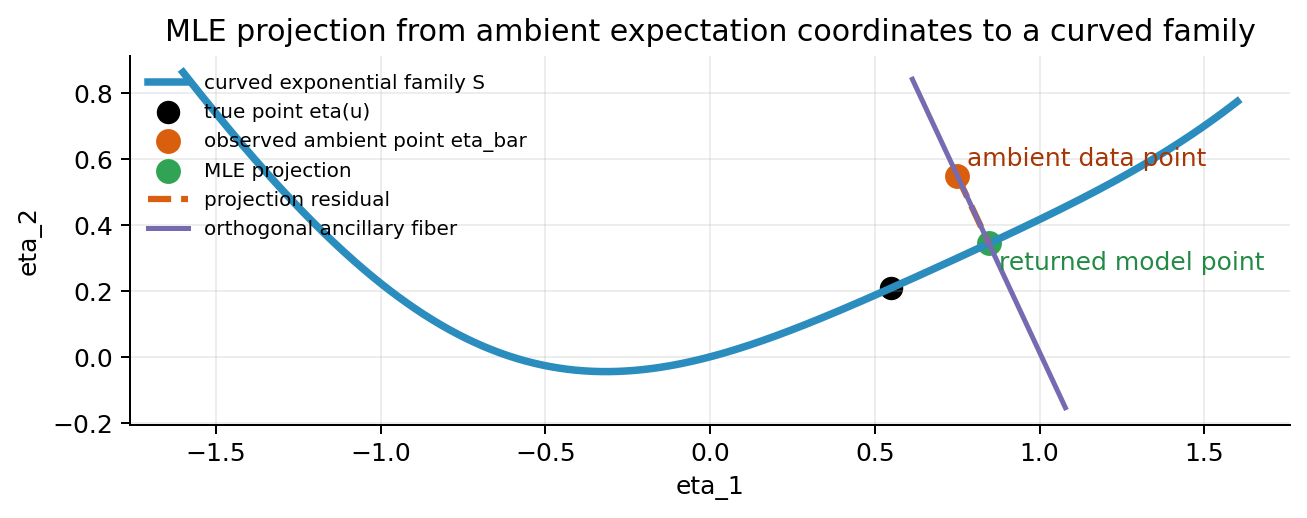

In [4]:
def eta_curve(u):
    u = np.asarray(u, dtype=float)
    return np.column_stack([u, 0.32*u**2 + 0.12*np.sin(2.2*u)]) if u.ndim else np.array([u, 0.32*u**2 + 0.12*np.sin(2.2*u)])

def tangent(u):
    return np.array([1.0, 0.64*u + 0.264*np.cos(2.2*u)])

def unit_normal(u):
    t = tangent(u)
    n = np.array([-t[1], t[0]])
    return n / np.linalg.norm(n)

def project_to_curve(point, grid=None):
    if grid is None:
        grid = np.linspace(-1.8, 1.8, 2401)
    pts = eta_curve(grid)
    d2 = np.sum((pts - point)**2, axis=1)
    k = int(np.argmin(d2))
    return float(grid[k]), pts[k], float(d2[k])

u_true = 0.55
eta_on_model = eta_curve(u_true)
observed_point = eta_on_model + np.array([0.20, 0.34])
u_mle, eta_mle, residual2 = project_to_curve(observed_point)
curve_u = np.linspace(-1.6, 1.6, 500)
curve_pts = eta_curve(curve_u)

fig, ax = plt.subplots(figsize=(7.4, 5.8))
ax.plot(curve_pts[:, 0], curve_pts[:, 1], color='#2b8cbe', lw=3, label='curved exponential family S')
ax.scatter([eta_on_model[0]], [eta_on_model[1]], color='black', s=70, label='true point eta(u)')
ax.scatter([observed_point[0]], [observed_point[1]], color='#d95f0e', s=80, label='observed ambient point eta_bar')
ax.scatter([eta_mle[0]], [eta_mle[1]], color='#31a354', s=80, label='MLE projection')
ax.plot([observed_point[0], eta_mle[0]], [observed_point[1], eta_mle[1]], color='#d95f0e', lw=2.5, ls='--', label='projection residual')
normal = unit_normal(u_mle)
fiber = np.array([eta_mle - 0.55*normal, eta_mle + 0.55*normal])
ax.plot(fiber[:, 0], fiber[:, 1], color='#756bb1', lw=2.0, label='orthogonal ancillary fiber')
ax.annotate('ambient data point', observed_point + np.array([0.03, 0.03]), color='#a63603')
ax.annotate('returned model point', eta_mle + np.array([0.03, -0.08]), color='#238b45')
ax.set_title('MLE projection from ambient expectation coordinates to a curved family')
ax.set_xlabel('eta_1')
ax.set_ylabel('eta_2')
ax.set_aspect('equal', adjustable='box')
ax.legend(frameon=False, fontsize=8, loc='upper left')
curved_projection_path = FIG_DIR / 'curved_family_mle_projection.png'
savefig(curved_projection_path)
display_artifact(curved_projection_path)


## 4. Ancillary Fibers: An Estimator Is a Foliation Near the Model

Fix a model point `eta(u)`. The set of ambient observations assigned to that same estimate is the fiber `A(u)`. If every nearby ambient point belongs to exactly one such fiber, the estimator has created local coordinates `(u, v)`: moving in `u` travels along the model, while moving in `v` travels along the fiber.

Consistency says that the fiber for `u` passes through the model point `eta(u)`. Efficiency adds the angle condition: at first order, the fiber should be orthogonal to the tangent of `S`. A tilted fiber leaks normal noise into the reported `u` value and inflates variance.


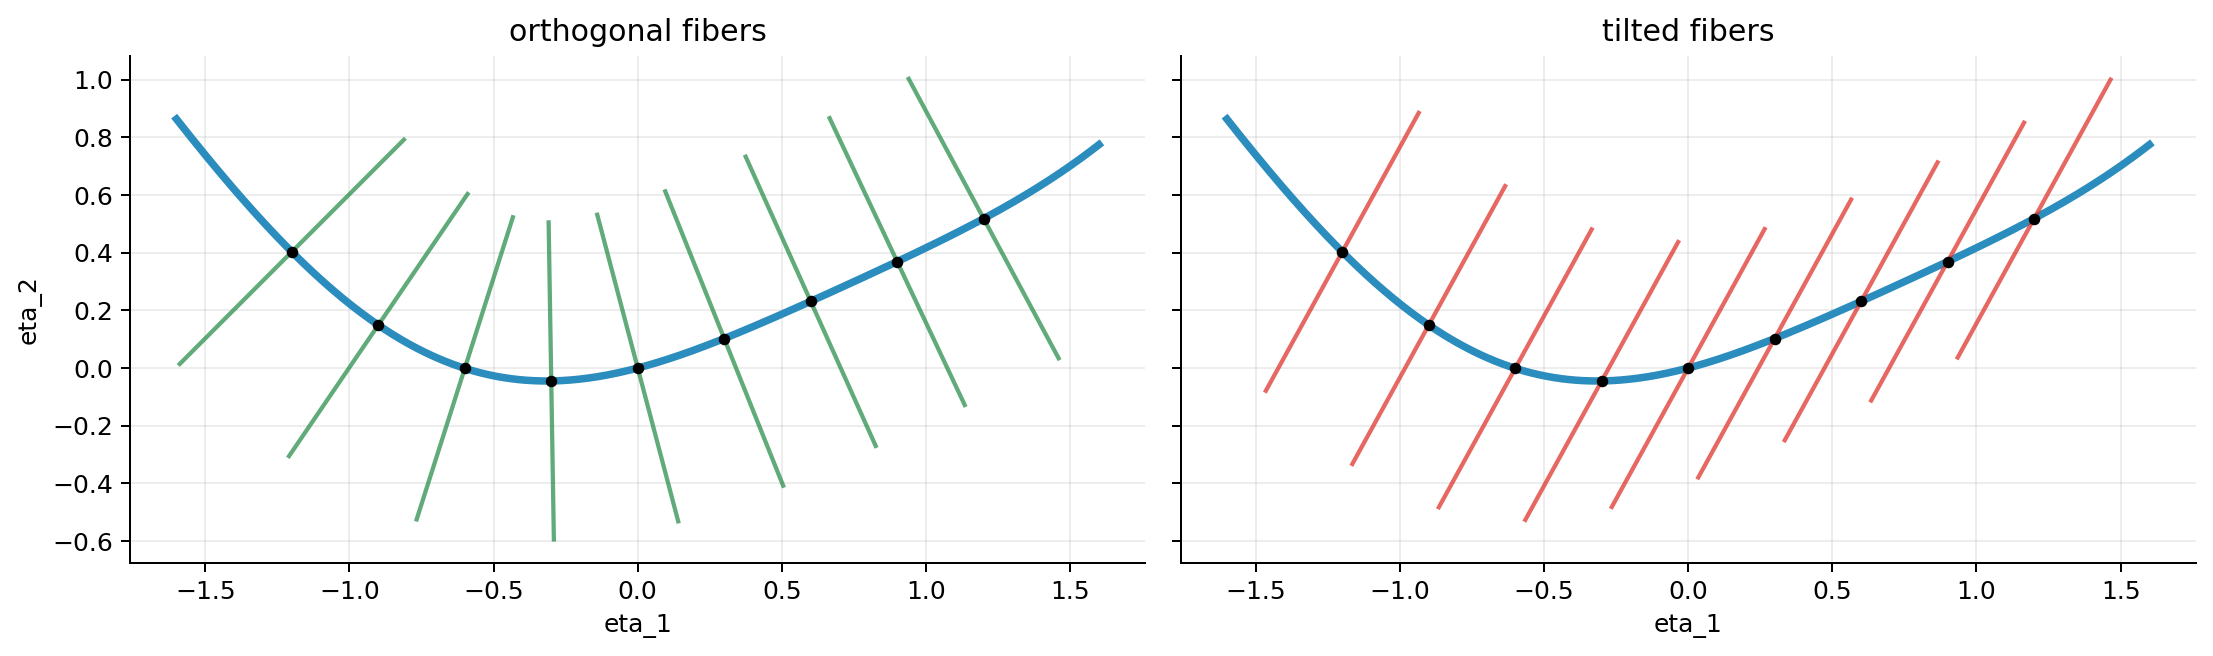

In [5]:
fiber_us = np.linspace(-1.2, 1.2, 9)
tilt = np.array([0.55, 1.0])
tilt = tilt / np.linalg.norm(tilt)
fig, axes = plt.subplots(1, 2, figsize=(12.4, 5.2), sharex=True, sharey=True)
for ax, mode in zip(axes, ['orthogonal fibers', 'tilted fibers']) :
    ax.plot(curve_pts[:, 0], curve_pts[:, 1], color='#2b8cbe', lw=3)
    for u in fiber_us:
        p = eta_curve(u)
        if mode.startswith('orthogonal'):
            direction = unit_normal(u)
            color = '#238b45'
        else:
            direction = tilt
            color = '#de2d26'
        seg = np.array([p - 0.55*direction, p + 0.55*direction])
        ax.plot(seg[:, 0], seg[:, 1], color=color, alpha=0.72, lw=1.7)
        ax.scatter([p[0]], [p[1]], color='black', s=13, zorder=3)
    ax.set_title(mode)
    ax.set_xlabel('eta_1')
    ax.set_aspect('equal', adjustable='box')
axes[0].set_ylabel('eta_2')
fibers_path = FIG_DIR / 'ancillary_fiber_foliations.png'
savefig(fibers_path)
display_artifact(fibers_path)


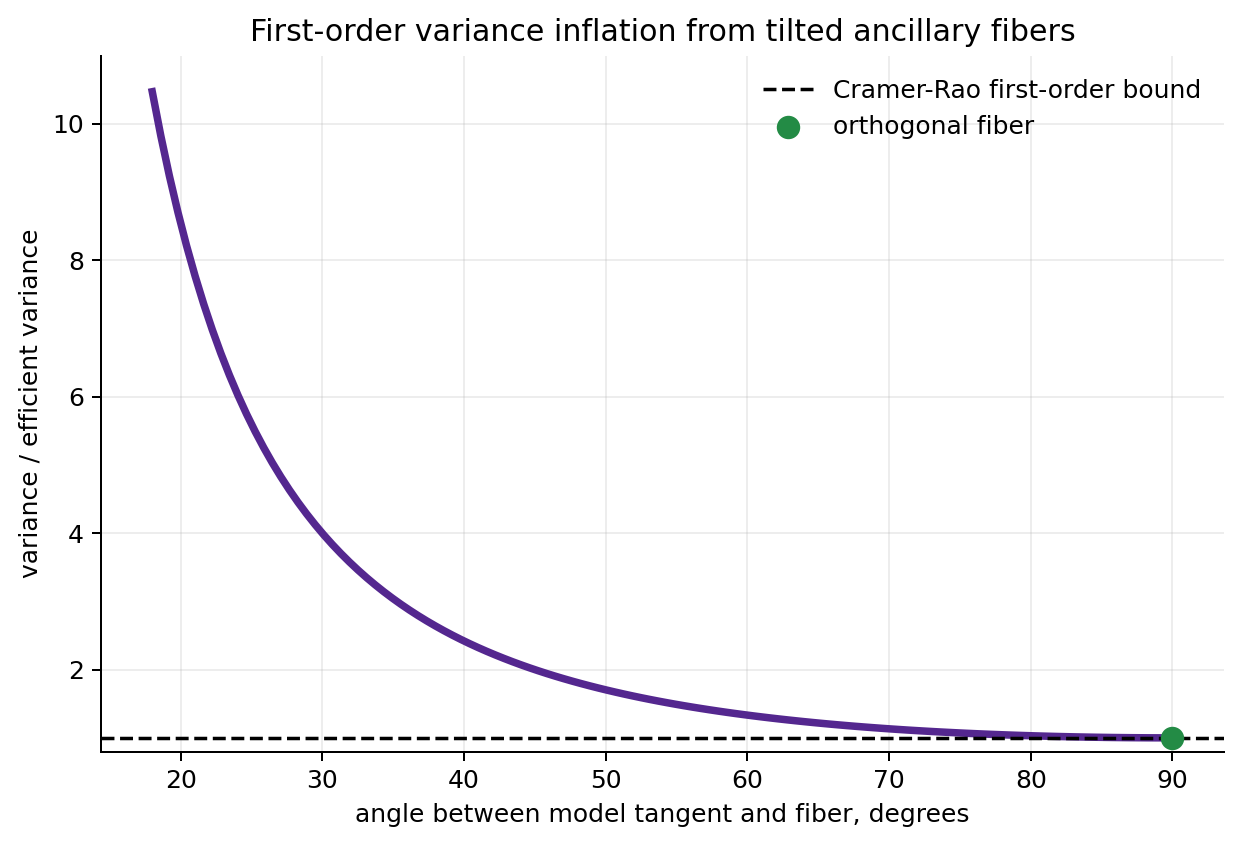

In [6]:
def variance_factor(u, fiber_direction):
    t = tangent(u)
    r = np.asarray(fiber_direction, dtype=float)
    cross = abs(t[0]*r[1] - t[1]*r[0])
    return float(np.dot(r, r) / (cross**2))

def cr_factor(u):
    t = tangent(u)
    return float(1.0 / np.dot(t, t))

angle_degrees = np.linspace(18, 90, 120)
selected_u = 0.55
t = tangent(selected_u)
t_angle = math.atan2(t[1], t[0])
ratios = []
for deg in angle_degrees:
    direction_angle = t_angle + math.radians(deg)
    r = np.array([math.cos(direction_angle), math.sin(direction_angle)])
    ratios.append(variance_factor(selected_u, r) / cr_factor(selected_u))

fig, ax = plt.subplots(figsize=(7.0, 4.8))
ax.plot(angle_degrees, ratios, color='#54278f', lw=3)
ax.axhline(1.0, color='black', lw=1.4, ls='--', label='Cramer-Rao first-order bound')
ax.scatter([90], [1], color='#238b45', s=70, zorder=3, label='orthogonal fiber')
ax.set_title('First-order variance inflation from tilted ancillary fibers')
ax.set_xlabel('angle between model tangent and fiber, degrees')
ax.set_ylabel('variance / efficient variance')
ax.set_ylim(0.8, max(ratios)*1.05)
ax.legend(frameon=False)
efficiency_path = FIG_DIR / 'fisher_efficiency_angle_inflation.png'
savefig(efficiency_path)
display_artifact(efficiency_path)


## 5. First-Order Covariance From the `(u, v)` Coordinates

Section 7.4 does more than draw fibers. It introduces a normalized ambient error `e_tilde = sqrt(N)(eta_bar - eta)` and then rewrites that small error in local coordinates `w_tilde = (u_tilde, v_tilde)`. In the notebook's planar model, the Jacobian block `B` has two columns: the model tangent `partial eta / partial u` and the fiber direction `partial eta / partial v`.

With the ambient Fisher metric represented by the identity matrix, the local metric is `G_w = B.T @ B`. Eliminating the fiber coordinate gives the Schur-complement precision `gbar_uu = g_uu - g_uv g_vv^{-1} g_vu`, so the first-order variance of `u_tilde` is `1 / gbar_uu`. Orthogonal fibers make the off-diagonal block vanish; tilted fibers lower the Schur precision and inflate the estimator variance.

,fiber,g_uu,g_uv,g_vv,schur_precision_gbar_uu,theory_covariance_for_u_tilde,inverse_metric_covariance,simulated_covariance_for_u_tilde,simulation_relative_error
0,orthogonal fiber,1.1982,-8.361872e-18,1.0,1.198200,0.834585,0.834585,0.837389,0.003359
1,tilted fiber,1.1982,8.720076e-01,1.0,0.437803,2.284131,2.284131,2.282742,0.000608


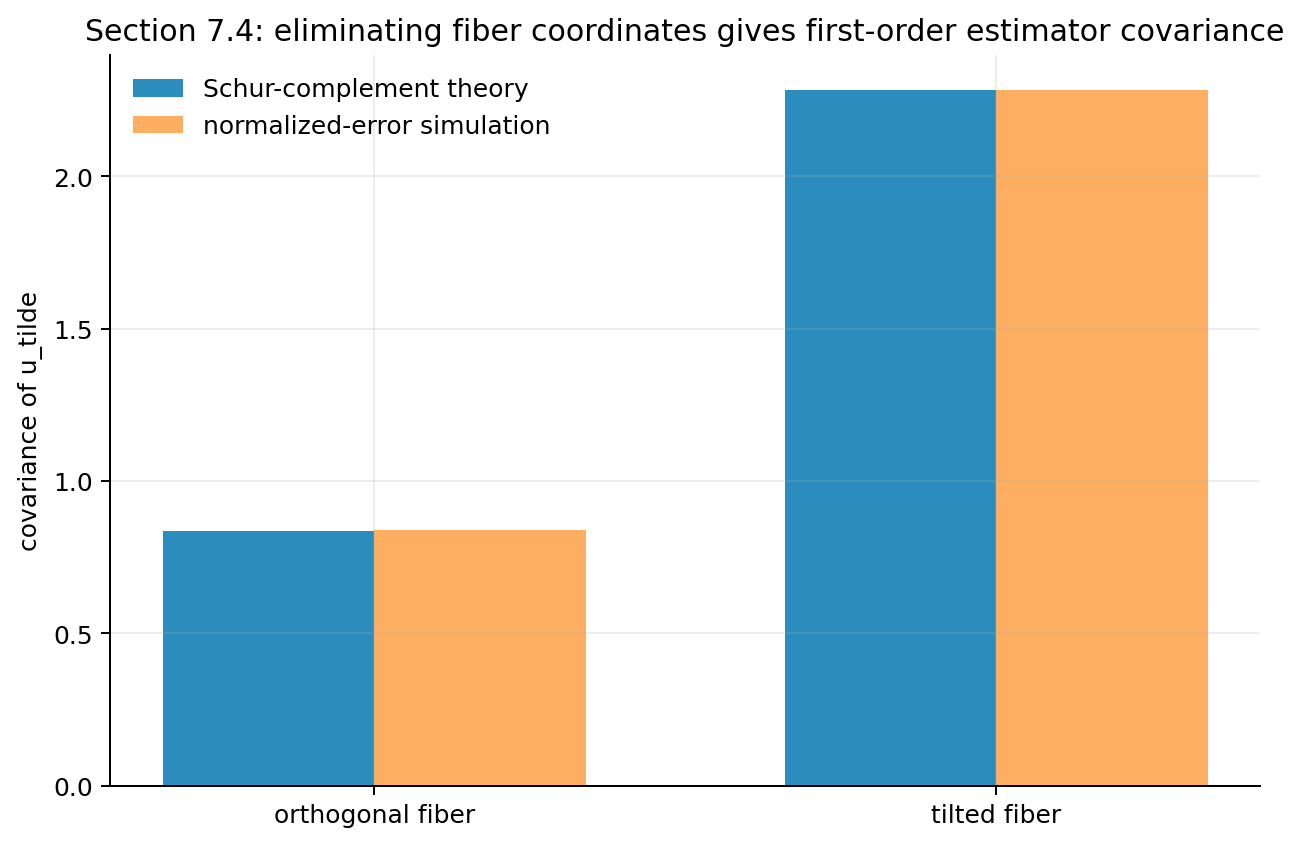

In [7]:
def schur_covariance_record(u, fiber_direction, label, sample_count=60000):
    t = tangent(u)
    r = np.asarray(fiber_direction, dtype=float)
    r = r / np.linalg.norm(r)
    B = np.column_stack([t, r])
    metric = B.T @ B
    schur_precision = metric[0, 0] - metric[0, 1] * metric[1, 0] / metric[1, 1]
    covariance_from_schur = 1.0 / schur_precision
    covariance_from_inverse = np.linalg.inv(metric)[0, 0]
    local_rng = np.random.default_rng(20260517 + int(1000 * abs(float(u))) + len(label))
    e_tilde = local_rng.multivariate_normal(np.zeros(2), np.eye(2), size=sample_count)
    w_tilde = e_tilde @ np.linalg.inv(B).T
    simulated_covariance = float(np.var(w_tilde[:, 0], ddof=1))
    return {
        'fiber': label,
        'g_uu': float(metric[0, 0]),
        'g_uv': float(metric[0, 1]),
        'g_vv': float(metric[1, 1]),
        'schur_precision_gbar_uu': float(schur_precision),
        'theory_covariance_for_u_tilde': float(covariance_from_schur),
        'inverse_metric_covariance': float(covariance_from_inverse),
        'simulated_covariance_for_u_tilde': simulated_covariance,
        'simulation_relative_error': float(abs(simulated_covariance - covariance_from_schur) / covariance_from_schur),
    }

schur_table = pd.DataFrame([
    schur_covariance_record(selected_u, unit_normal(selected_u), 'orthogonal fiber'),
    schur_covariance_record(selected_u, tilt, 'tilted fiber'),
])
schur_table_path = TABLE_DIR / 'first_order_schur_covariance_check.csv'
schur_table.to_csv(schur_table_path, index=False)
display_artifact(schur_table_path)

fig, ax = plt.subplots(figsize=(7.2, 4.8))
x = np.arange(len(schur_table))
width = 0.34
ax.bar(x - width/2, schur_table['theory_covariance_for_u_tilde'], width, label='Schur-complement theory', color='#2b8cbe')
ax.bar(x + width/2, schur_table['simulated_covariance_for_u_tilde'], width, label='normalized-error simulation', color='#fdae61')
ax.set_xticks(x)
ax.set_xticklabels(schur_table['fiber'])
ax.set_ylabel('covariance of u_tilde')
ax.set_title('Section 7.4: eliminating fiber coordinates gives first-order estimator covariance')
ax.legend(frameon=False)
schur_path = FIG_DIR / 'first_order_schur_covariance_check.png'
savefig(schur_path)
display_artifact(schur_path)

schur_inverse_error = float(np.max(np.abs(schur_table['theory_covariance_for_u_tilde'] - schur_table['inverse_metric_covariance'])))
schur_simulation_max_relative_error = float(schur_table['simulation_relative_error'].max())


## 6. Interactive View: A Local `(u, v)` Coordinate Sheet

The next artifact turns the fibers into a small ruled sheet. The blue curve is the statistical model `S`; the translucent sheet is a neighborhood of ambient observations coordinatized by `(u, v)`. Sliding in `v` keeps the estimate fixed, while sliding in `u` changes the reported parameter.


In [8]:
U = np.linspace(-1.35, 1.35, 90)
V = np.linspace(-0.45, 0.45, 21)
X = np.zeros((len(V), len(U)))
Y = np.zeros_like(X)
Z = np.zeros_like(X)
for j, u in enumerate(U):
    p = eta_curve(u)
    n = unit_normal(u)
    for i, v in enumerate(V):
        q = p + v*n
        X[i, j] = q[0]
        Y[i, j] = q[1]
        Z[i, j] = v
curve = eta_curve(U)
fig = go.Figure()
fig.add_trace(go.Surface(x=X, y=Y, z=Z, colorscale='Viridis', opacity=0.70, showscale=False,
                         hovertemplate='eta1=%{x:.3f}<br>eta2=%{y:.3f}<br>fiber v=%{z:.3f}<extra></extra>'))
fig.add_trace(go.Scatter3d(x=curve[:,0], y=curve[:,1], z=np.zeros_like(U), mode='lines',
                           line=dict(color='black', width=7), name='model S: v=0'))
fig.update_layout(title='Ancillary fiber coordinates around a curved exponential family',
                  scene=dict(xaxis_title='eta_1', yaxis_title='eta_2', zaxis_title='fiber coordinate v'),
                  width=850, height=650, margin=dict(l=0, r=0, t=55, b=0))
fiber_sheet_html = HTML_DIR / 'ancillary_fiber_coordinate_sheet.html'
fig.write_html(fiber_sheet_html, include_plotlyjs=True)
html_text = fiber_sheet_html.read_text(encoding='utf-8')
fiber_sheet_html.write_text('\n'.join(line.rstrip() for line in html_text.splitlines()) + '\n', encoding='utf-8')
display_artifact(fiber_sheet_html, 'html')


## 7. Higher-Order Terms: Bias Correction and Curvature Contributions

First-order asymptotics only sees the tangent line or tangent plane. Higher-order asymptotics asks what changes after the estimator has been bias-corrected, so that first-order efficient estimators can be compared fairly.

The chapter's second-order covariance statement separates three nonnegative sources of extra error: curvature of the statistical model `S`, curvature introduced by the chosen coordinates on `S`, and curvature of the ancillary family used by the estimator. The bias-corrected MLE is special because its associated ancillary family is m-flat in this comparison, so the estimator-dependent ancillary-curvature term vanishes.

For a planar curve, the scalar curvature below is not the full tensor formula from the chapter. It is a deliberately small diagnostic for the same lesson: when the embedded family is nearly straight, the tangent approximation is excellent; where the curve bends, second-order distinctions become visible.


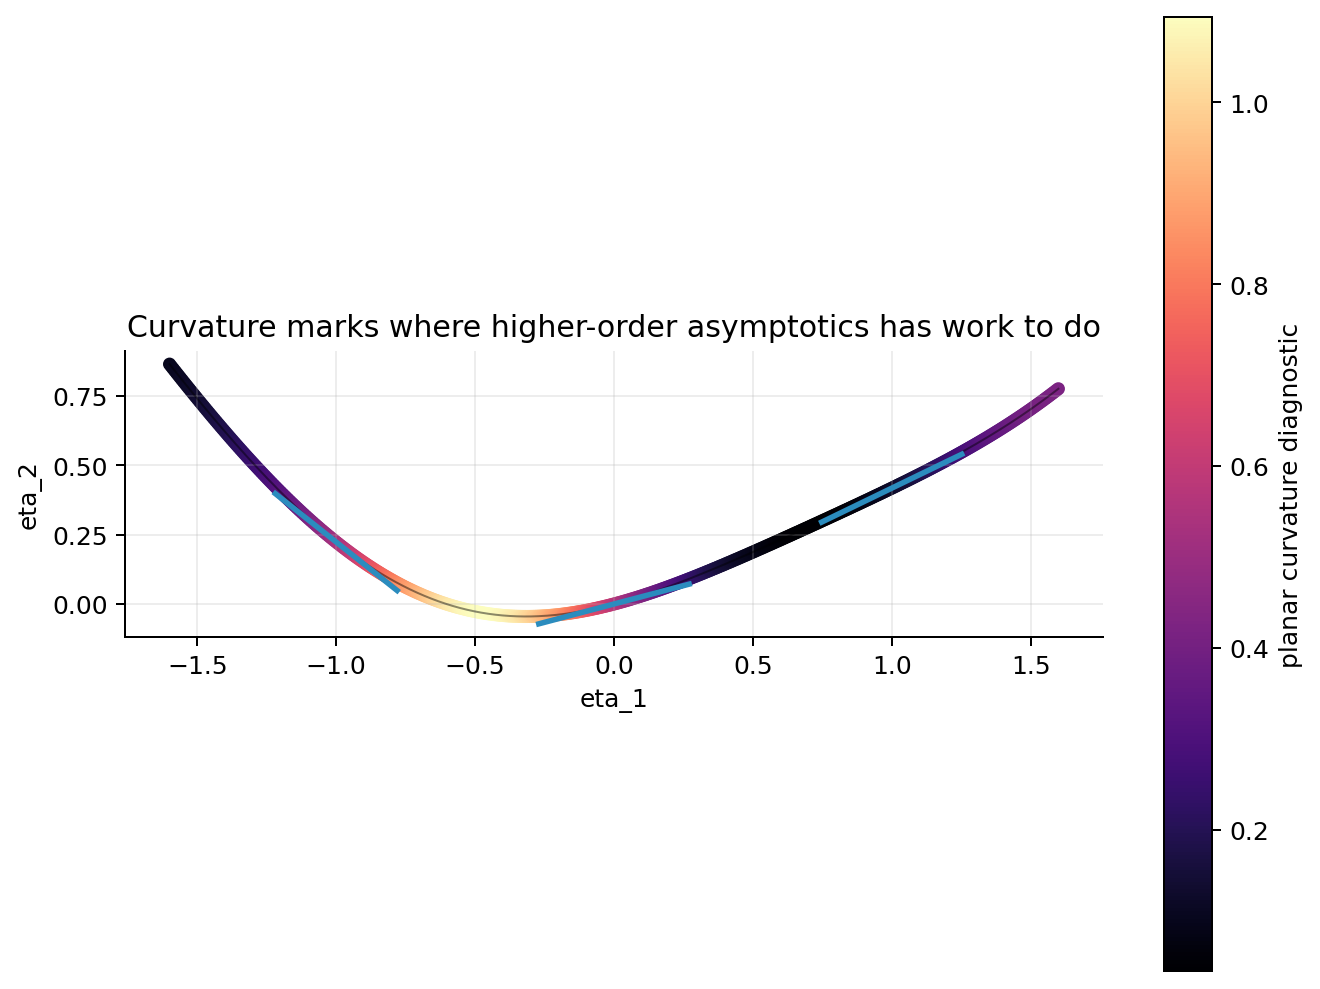

In [9]:
def curve_derivatives(u):
    dy = 0.64*u + 0.264*np.cos(2.2*u)
    ddy = 0.64 - 0.5808*np.sin(2.2*u)
    return dy, ddy

curv_u = np.linspace(-1.6, 1.6, 500)
dy, ddy = curve_derivatives(curv_u)
curvature = np.abs(ddy) / (1 + dy**2)**1.5
curv_pts = eta_curve(curv_u)
fig, ax = plt.subplots(figsize=(7.6, 5.6))
sc = ax.scatter(curv_pts[:,0], curv_pts[:,1], c=curvature, s=18, cmap='magma', label='curvature along S')
ax.plot(curv_pts[:,0], curv_pts[:,1], color='black', lw=0.8, alpha=0.45)
cb = plt.colorbar(sc, ax=ax)
cb.set_label('planar curvature diagnostic')
for u in [-1.0, 0.0, 1.0]:
    p = eta_curve(u)
    t = tangent(u); t = t / np.linalg.norm(t)
    seg = np.array([p - 0.28*t, p + 0.28*t])
    ax.plot(seg[:,0], seg[:,1], color='#2b8cbe', lw=2.2)
ax.set_title('Curvature marks where higher-order asymptotics has work to do')
ax.set_xlabel('eta_1')
ax.set_ylabel('eta_2')
ax.set_aspect('equal', adjustable='box')
curvature_path = FIG_DIR / 'curved_family_curvature_diagnostic.png'
savefig(curvature_path)
display_artifact(curvature_path)


### Bias-Corrected Second-Order Ledger

The theorem in the source chapter is tensorial, but its bookkeeping has a simple visual form: after bias correction, the first-order Fisher term is already fixed, and the remaining covariance comparison is a sum of curvature contributions. The small table below turns that bookkeeping into a toy ledger along the same curve.

The values are diagnostics, not quoted theorem coefficients. They preserve the source structure: the model and coordinate terms are shared by efficient estimators, while the ancillary term is the estimator-dependent part. The MLE column sets that ancillary term to zero, matching the second-order efficiency claim for the bias-corrected MLE.

,location,u,estimator,term,value
0,left bend,-1.0,bias-corrected MLE,model e-curvature,0.282924
1,left bend,-1.0,bias-corrected MLE,coordinate m-connection,0.292202
2,left bend,-1.0,bias-corrected MLE,ancillary m-curvature,0.000000
3,left bend,-1.0,bias-corrected bent-fiber estimator,model e-curvature,0.282924
4,left bend,-1.0,bias-corrected bent-fiber estimator,coordinate m-connection,0.292202
5,left bend,-1.0,bias-corrected bent-fiber estimator,ancillary m-curvature,0.102007
6,center,0.0,bias-corrected MLE,model e-curvature,0.334641
7,center,0.0,bias-corrected MLE,coordinate m-connection,0.024949
8,center,0.0,bias-corrected MLE,ancillary m-curvature,0.000000
9,center,0.0,bias-corrected bent-fiber estimator,model e-curvature,0.334641


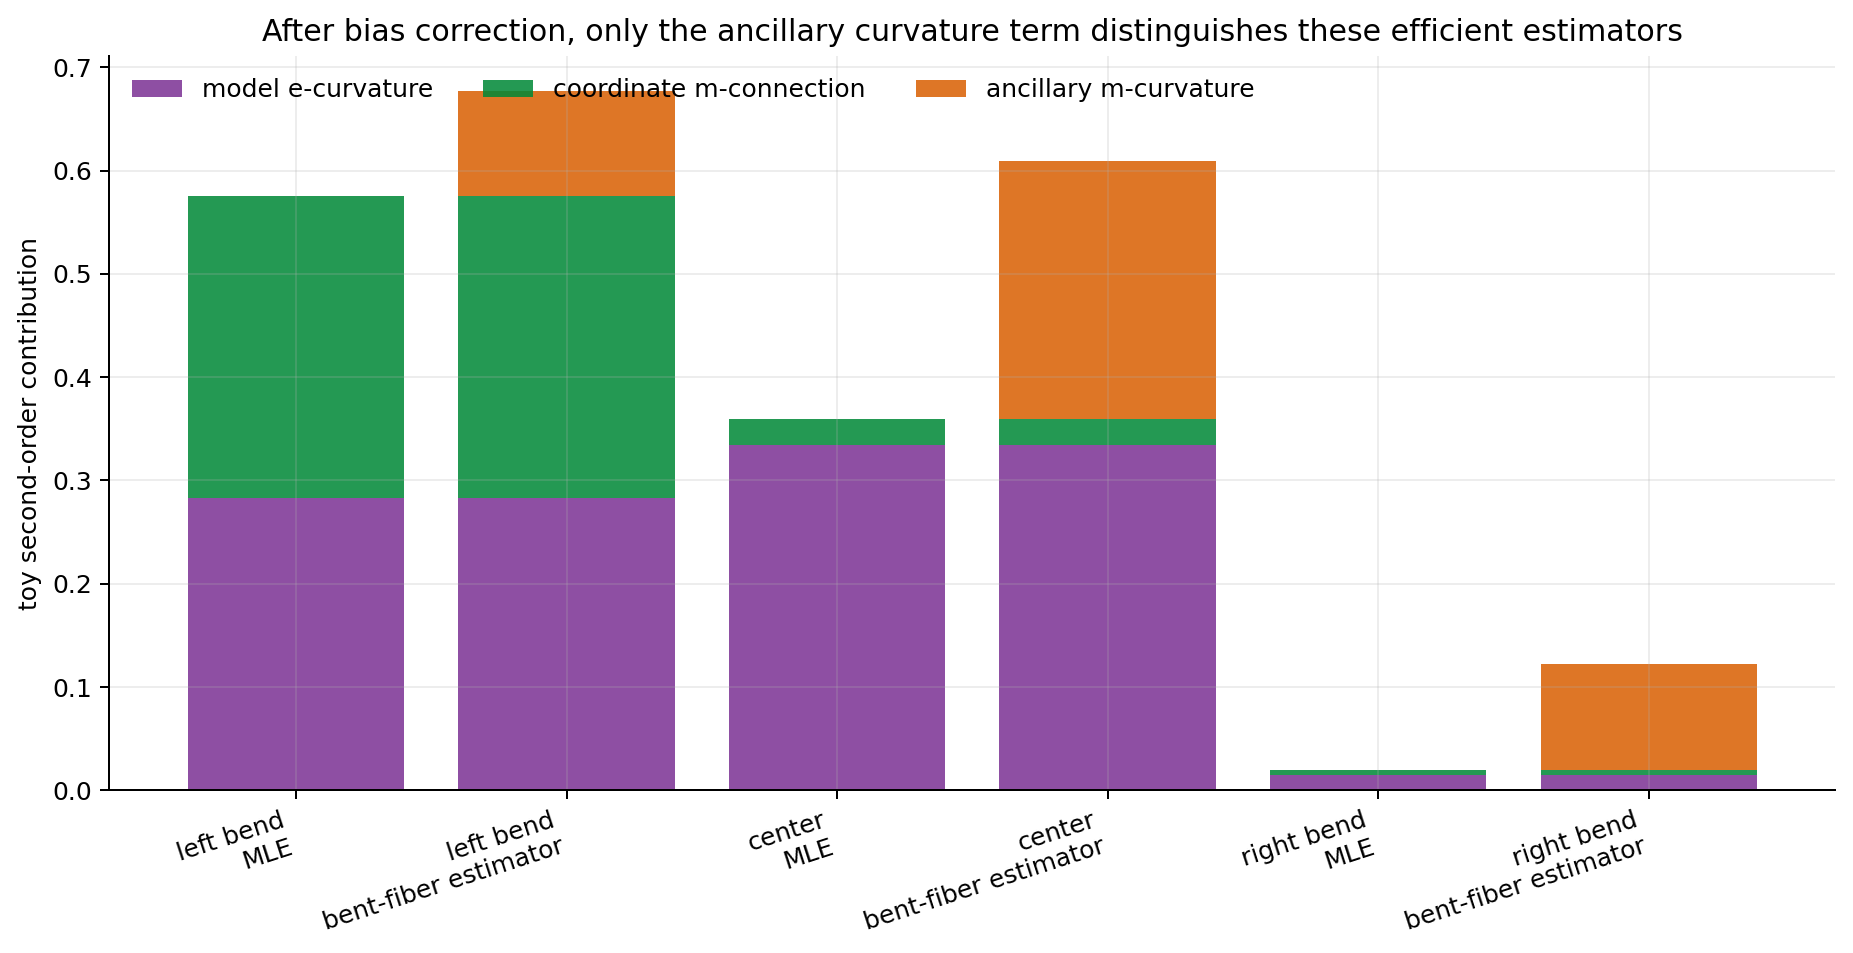

In [10]:
def curvature_at(u):
    dy, ddy = curve_derivatives(np.asarray(u, dtype=float))
    return np.abs(ddy) / (1 + dy**2)**1.5


def d_log_speed(u):
    dy, ddy = curve_derivatives(np.asarray(u, dtype=float))
    return dy * ddy / (1 + dy**2)

term_locations = [(-1.0, 'left bend'), (0.0, 'center'), (1.0, 'right bend')]
second_order_rows = []
for u, label in term_locations:
    model_term = float(curvature_at(u)**2)
    coordinate_term = float(d_log_speed(u)**2)
    bent_ancillary_term = float((0.34 + 0.16*np.cos(1.7*u))**2)
    for estimator, ancillary_term in [
        ('bias-corrected MLE', 0.0),
        ('bias-corrected bent-fiber estimator', bent_ancillary_term),
    ]:
        second_order_rows.extend([
            {'location': label, 'u': u, 'estimator': estimator, 'term': 'model e-curvature', 'value': model_term},
            {'location': label, 'u': u, 'estimator': estimator, 'term': 'coordinate m-connection', 'value': coordinate_term},
            {'location': label, 'u': u, 'estimator': estimator, 'term': 'ancillary m-curvature', 'value': ancillary_term},
        ])

second_order_terms = pd.DataFrame(second_order_rows)
second_order_table_path = TABLE_DIR / 'second_order_covariance_decomposition.csv'
second_order_terms.to_csv(second_order_table_path, index=False)
display_artifact(second_order_table_path)

pivot = second_order_terms.pivot_table(
    index=['location', 'estimator'], columns='term', values='value', aggfunc='sum'
).loc[
    [(label, estimator) for _, label in term_locations for estimator in ['bias-corrected MLE', 'bias-corrected bent-fiber estimator']]
]
colors = {
    'model e-curvature': '#7b3294',
    'coordinate m-connection': '#008837',
    'ancillary m-curvature': '#d95f02',
}
fig, ax = plt.subplots(figsize=(10.4, 5.4))
x = np.arange(len(pivot))
bottom = np.zeros(len(pivot))
for term in ['model e-curvature', 'coordinate m-connection', 'ancillary m-curvature']:
    vals = pivot[term].to_numpy()
    ax.bar(x, vals, bottom=bottom, label=term, color=colors[term], alpha=0.86)
    bottom += vals
labels = [f"{loc}\n{est.replace('bias-corrected ', '')}" for loc, est in pivot.index]
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=18, ha='right')
ax.set_ylabel('toy second-order contribution')
ax.set_title('After bias correction, only the ancillary curvature term distinguishes these efficient estimators')
ax.legend(frameon=False, ncol=3, loc='upper left')
second_order_path = FIG_DIR / 'second_order_covariance_decomposition.png'
savefig(second_order_path)
display_artifact(second_order_path)

second_order_terms_nonnegative = bool((second_order_terms['value'] >= -1e-12).all())
mle_ancillary_zero = float(second_order_terms[
    (second_order_terms['estimator'] == 'bias-corrected MLE')
    & (second_order_terms['term'] == 'ancillary m-curvature')
]['value'].abs().max())


## 8. Applied Lab: Compare Orthogonal and Tilted Estimators

The lab simulates ambient observed points around a true point on the curved family. Two estimators are compared:

- **Orthogonal estimator:** project each point to the nearest point on `S`, a local stand-in for MLE projection.
- **Tilted-fiber estimator:** assign the point to the curve point whose tilted fiber passes closest to the observation.

Both estimators are consistent in this local experiment. The tilted one is worse at first order because its fibers are not orthogonal to the model tangent.


In [11]:
def estimate_tilted(point, grid, direction):
    pts = eta_curve(grid)
    r = np.asarray(direction, dtype=float)
    r = r / np.linalg.norm(r)
    residual = pts - point
    perpendicular = residual[:,0]*(-r[1]) + residual[:,1]*r[0]
    return float(grid[int(np.argmin(perpendicular**2))])

sim_grid = np.linspace(-1.3, 1.3, 1801)
lab_rows = []
true_u = 0.55
true_eta = eta_curve(true_u)
ambient_cov = np.array([[1.0, 0.0], [0.0, 1.0]])
tilt_direction = np.array([math.cos(t_angle + math.radians(45)), math.sin(t_angle + math.radians(45))])
for N in [40, 120, 360, 1080]:
    obs = rng.multivariate_normal(true_eta, ambient_cov / N, size=1600)
    orth = np.array([project_to_curve(p, sim_grid)[0] for p in obs])
    tilted = np.array([estimate_tilted(p, sim_grid, tilt_direction) for p in obs])
    efficient_theory = cr_factor(true_u) / N
    tilted_theory = variance_factor(true_u, tilt_direction) / N
    lab_rows.append({
        'N': N,
        'orthogonal_bias': float(orth.mean() - true_u),
        'tilted_bias': float(tilted.mean() - true_u),
        'orthogonal_variance': float(orth.var(ddof=1)),
        'tilted_variance': float(tilted.var(ddof=1)),
        'efficient_theory_variance': float(efficient_theory),
        'tilted_theory_variance': float(tilted_theory),
        'tilted_to_orthogonal_variance_ratio': float(tilted.var(ddof=1) / orth.var(ddof=1)),
    })
lab_table = pd.DataFrame(lab_rows)
lab_path = TABLE_DIR / 'orthogonal_vs_tilted_estimator_lab.csv'
lab_table.to_csv(lab_path, index=False)
display_artifact(lab_path)


,N,orthogonal_bias,tilted_bias,orthogonal_variance,tilted_variance,efficient_theory_variance,tilted_theory_variance,tilted_to_orthogonal_variance_ratio
0,40,0.001956,0.004508,0.020779,0.042145,0.020865,0.041729,2.028271
1,120,-0.000273,-0.004019,0.006627,0.013177,0.006955,0.013910,1.988350
2,360,-0.002605,-0.003968,0.002252,0.004525,0.002318,0.004637,2.008784
3,1080,0.002170,0.003010,0.000748,0.001508,0.000773,0.001546,2.017565


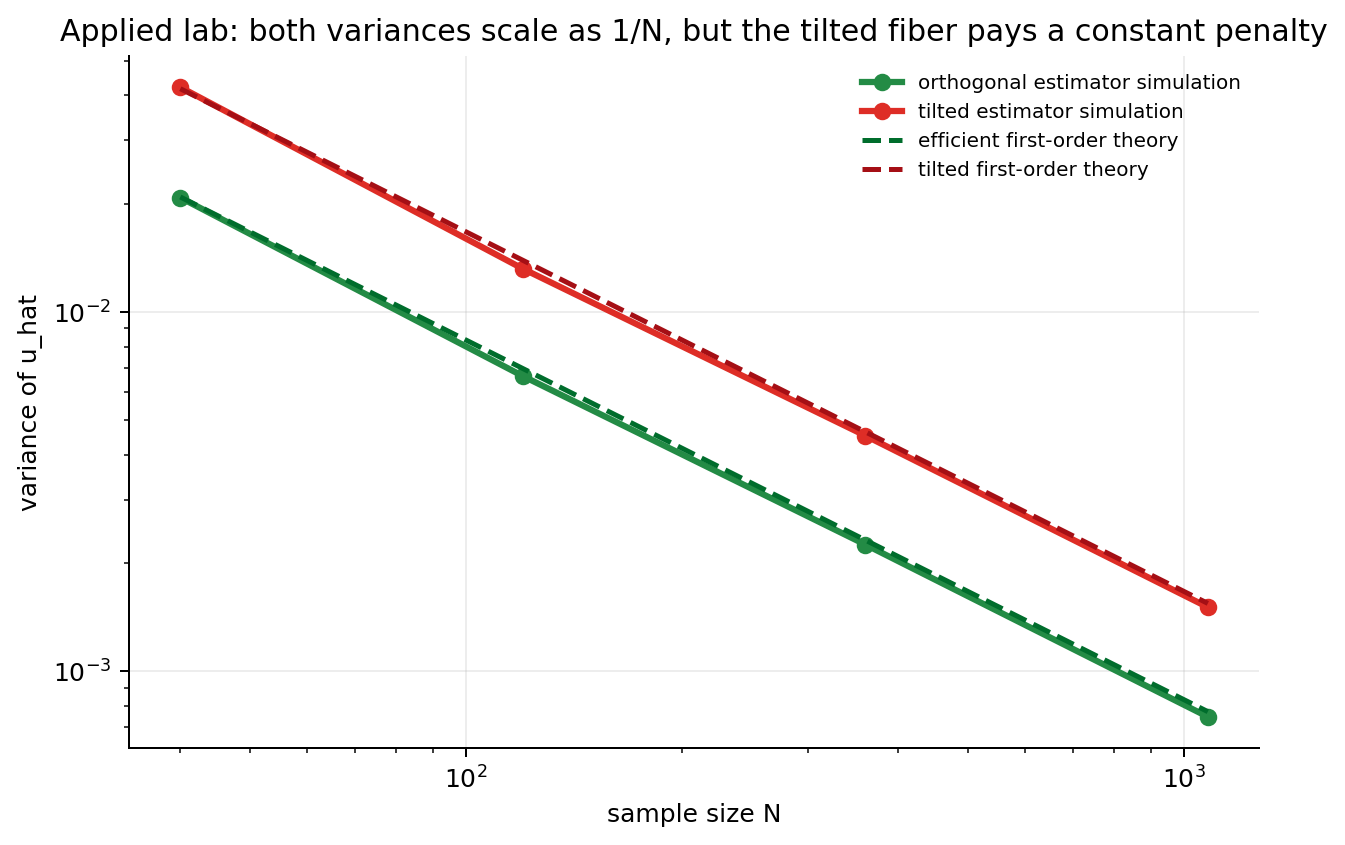

In [12]:
fig, ax = plt.subplots(figsize=(7.2, 4.8))
ax.plot(lab_table['N'], lab_table['orthogonal_variance'], marker='o', lw=2.5, label='orthogonal estimator simulation', color='#238b45')
ax.plot(lab_table['N'], lab_table['tilted_variance'], marker='o', lw=2.5, label='tilted estimator simulation', color='#de2d26')
ax.plot(lab_table['N'], lab_table['efficient_theory_variance'], ls='--', lw=2, color='#006d2c', label='efficient first-order theory')
ax.plot(lab_table['N'], lab_table['tilted_theory_variance'], ls='--', lw=2, color='#a50f15', label='tilted first-order theory')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_title('Applied lab: both variances scale as 1/N, but the tilted fiber pays a constant penalty')
ax.set_xlabel('sample size N')
ax.set_ylabel('variance of u_hat')
ax.legend(frameon=False, fontsize=8)
lab_variance_path = FIG_DIR / 'applied_lab_variance_scaling.png'
savefig(lab_variance_path)
display_artifact(lab_variance_path)


## 9. Hypothesis Testing: Boundaries Are Ancillary Fibers Too

A large-sample test can also be drawn as a geometric object. Under a null value `u0`, the observed point should be near `eta(u0)`. A rejection region is separated from the acceptance region by a boundary surface. As `N` grows, that boundary approaches the null point. Treating `u0` as variable turns the family of test boundaries into another ancillary family.

This is why estimation and testing share the same first-order geometry. A first-order efficient test has a boundary that becomes orthogonal to the model at the null point. The source names Rao, Wald, likelihood-ratio, and locally most powerful tests as examples: they can agree in the tangent approximation while differing at second order through boundary angle, curvature, and power behavior. Outside exponential families, the chapter emphasizes that there is generally no uniformly most powerful second-order test.


In [13]:
named_test_rows = [
    {
        'test': 'Rao score test',
        'first_order_geometry': 'uses the score direction at the null point',
        'second_order_handle': 'boundary angle and local curvature can change power away from the tangent approximation',
    },
    {
        'test': 'Wald test',
        'first_order_geometry': 'measures displacement of an estimator from the null point',
        'second_order_handle': 'coordinate choice and estimator-induced fibers matter beyond first order',
    },
    {
        'test': 'likelihood-ratio test',
        'first_order_geometry': 'compares likelihood height after projection to the null',
        'second_order_handle': 'curvature of the model and rejection boundary controls higher-order power',
    },
    {
        'test': 'locally most powerful test',
        'first_order_geometry': 'optimizes power in a specified local alternative direction',
        'second_order_handle': 'no uniformly most powerful second-order test in general curved families',
    },
]
test_geometry_table = pd.DataFrame(named_test_rows)
test_geometry_path = TABLE_DIR / 'named_test_boundary_geometry.csv'
test_geometry_table.to_csv(test_geometry_path, index=False)
display_artifact(test_geometry_path)


,test,first_order_geometry,second_order_handle
0,Rao score test,uses the score direction at the null point,boundary angle and local curvature can change ...
1,Wald test,measures displacement of an estimator from the...,coordinate choice and estimator-induced fibers...
2,likelihood-ratio test,compares likelihood height after projection to...,curvature of the model and rejection boundary ...
3,locally most powerful test,optimizes power in a specified local alternati...,no uniformly most powerful second-order test i...


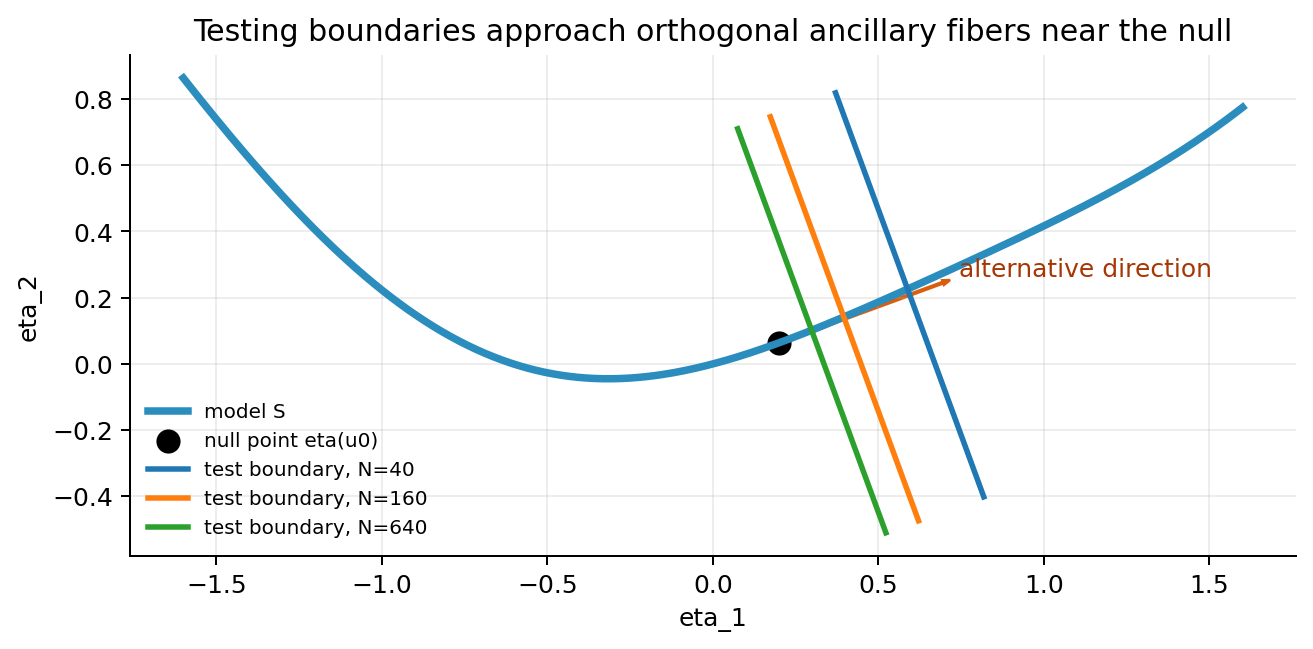

In [14]:
u0 = 0.2
p0 = eta_curve(u0)
n0 = unit_normal(u0)
t0 = tangent(u0); t0 = t0 / np.linalg.norm(t0)
thresholds = {40: 0.42, 160: 0.21, 640: 0.105}
fig, ax = plt.subplots(figsize=(7.4, 5.4))
ax.plot(curve_pts[:,0], curve_pts[:,1], color='#2b8cbe', lw=3, label='model S')
ax.scatter([p0[0]], [p0[1]], s=75, color='black', label='null point eta(u0)')
for N, offset in thresholds.items():
    center = p0 + offset*t0
    boundary = np.array([center - 0.65*n0, center + 0.65*n0])
    ax.plot(boundary[:,0], boundary[:,1], lw=2.2, label=f'test boundary, N={N}')
ax.arrow(p0[0], p0[1], 0.55*t0[0], 0.55*t0[1], width=0.005, color='#d95f0e', length_includes_head=True)
ax.text(*(p0 + 0.58*t0), 'alternative direction', color='#a63603')
ax.set_title('Testing boundaries approach orthogonal ancillary fibers near the null')
ax.set_xlabel('eta_1')
ax.set_ylabel('eta_2')
ax.set_aspect('equal', adjustable='box')
ax.legend(frameon=False, fontsize=8)
testing_path = FIG_DIR / 'hypothesis_testing_boundaries.png'
savefig(testing_path)
display_artifact(testing_path)


## 10. Remarks and Boundary Cases

A few source-span points are conceptual rather than visualized as new algorithms here:

- The chapter sets Bayes estimators aside, but notes that a flat prior makes the MLE the maximum a posteriori estimate, and regular priors share the same large-sample behavior.
- The bias-corrected MLE is second-order efficient in the curved-exponential setting, but the source remarks that MLE optimality does not extend indefinitely to every higher order.
- Curved exponential families are the working model for the chapter's geometry. For more general regular models, the same higher-order ideas can be organized through a local exponential-family construction using higher derivatives of the score.
- Non-regular models can break the Riemannian story: Fisher information may degenerate at singularities or diverge in boundary-like models. Later applications return to singular learning, while divergent-information cases point toward non-Gaussian and Finsler-like behavior.


## 11. Sanity Checks

The checks below are deliberately concrete. They verify the variance-angle identity used in the efficiency plot, confirm that the projection residual is nearly orthogonal to the curve tangent, check the Section 7.4 Schur-complement covariance calculation, check the simulated variance trend, and assert that all generated artifacts exist with nonzero size.


In [15]:
artifact_paths = [
    translation_path,
    storyboard_path,
    projection_cloud_path,
    curved_projection_path,
    fibers_path,
    efficiency_path,
    schur_table_path,
    schur_path,
    fiber_sheet_html,
    curvature_path,
    second_order_table_path,
    second_order_path,
    lab_path,
    lab_variance_path,
    test_geometry_path,
    testing_path,
]

projection_residual = observed_point - eta_mle
projection_tangent = tangent(u_mle)
projection_orthogonality = float(abs(np.dot(projection_residual, projection_tangent)) / (np.linalg.norm(projection_residual) * np.linalg.norm(projection_tangent)))
ratio_at_90 = variance_factor(selected_u, unit_normal(selected_u)) / cr_factor(selected_u)
variance_monotone = bool(np.all(np.diff(lab_table['orthogonal_variance'].to_numpy()) < 0) and np.all(np.diff(lab_table['tilted_variance'].to_numpy()) < 0))
artifact_sizes = {str(p): Path(p).stat().st_size for p in artifact_paths}

checks = {
    'projection_residual_cosine_with_tangent': projection_orthogonality,
    'orthogonal_variance_ratio_should_be_one': float(ratio_at_90),
    'schur_inverse_max_abs_error': schur_inverse_error,
    'schur_simulation_max_relative_error': schur_simulation_max_relative_error,
    'lab_variances_decrease_with_N': variance_monotone,
    'tilted_ratio_last_N': float(lab_table['tilted_to_orthogonal_variance_ratio'].iloc[-1]),
    'second_order_terms_nonnegative': second_order_terms_nonnegative,
    'mle_ancillary_curvature_term_max_abs': mle_ancillary_zero,
    'named_test_count': int(len(test_geometry_table)),
    'storyboard_source_span_read': storyboard['source_span_read'],
    'coverage_refresh_count': len(storyboard['coverage_refresh']),
    'artifact_count': len(artifact_paths),
    'artifact_sizes': artifact_sizes,
}

assert projection_orthogonality < 0.015, projection_orthogonality
assert abs(ratio_at_90 - 1.0) < 1e-10, ratio_at_90
assert schur_inverse_error < 1e-12, schur_inverse_error
assert schur_simulation_max_relative_error < 0.025, schur_simulation_max_relative_error
assert variance_monotone
assert lab_table['tilted_to_orthogonal_variance_ratio'].iloc[-1] > 1.45
assert second_order_terms_nonnegative
assert mle_ancillary_zero < 1e-12, mle_ancillary_zero
assert len(test_geometry_table) >= 4
assert len(storyboard['coverage_refresh']) >= 8
assert all(size > (100 if Path(path).suffix == '.csv' else 500) for path, size in artifact_sizes.items())

sanity_path = CHECK_DIR / 'chapter_07_sanity.json'
sanity_path.write_text(json.dumps(checks, indent=2), encoding='utf-8')
display_artifact(sanity_path)
checks


`artifacts/chapter-07/checks/chapter_07_sanity.json`

{'projection_residual_cosine_with_tangent': 0.0018781282408870286,
 'orthogonal_variance_ratio_should_be_one': 0.9999999999999996,
 'schur_inverse_max_abs_error': 4.440892098500626e-16,
 'schur_simulation_max_relative_error': 0.0033593624997189,
 'lab_variances_decrease_with_N': True,
 'tilted_ratio_last_N': 2.0175648408741043,
 'second_order_terms_nonnegative': True,
 'mle_ancillary_curvature_term_max_abs': 0.0,
 'named_test_count': 4,
 'storyboard_source_span_read': {'printed_pages': '165-177',
  'pdf_pages': '173-185',
  'source_pdf': 'Information-Geometry-and-Its-Applications/Information Geometry and Its Applications.pdf',
  'used_for': 'orientation on section order, terminology, formulas, theorem roles, and concept boundaries only'},
 'coverage_refresh_count': 8,
 'artifact_count': 16,
 'artifact_sizes': {'artifacts\\chapter-07\\tables\\asymptotic_geometry_translation.csv': 932,
  'artifacts\\chapter-07\\checks\\chapter-07-visual-storyboard.json': 5114,
  'artifacts\\chapter-07\\f

## 12. Takeaways

- In a full exponential family, the MLE is especially transparent in expectation coordinates: match the observed sufficient statistic.
- In a curved exponential family, the observed point usually lands off the model, so an estimator is a geometric return map from the ambient family to the curved submanifold.
- The inverse images of that return map are ancillary fibers. They are not decoration; they encode the estimator.
- Consistency requires fibers to pass through the model point. First-order Fisher efficiency requires those fibers to be orthogonal to the model in the Fisher metric.
- Section 7.4's normalized-error calculation becomes concrete through the Schur complement: eliminating the fiber coordinate gives the covariance of `u_tilde`.
- Bias correction removes the order `1/N` drift before efficient estimators are compared at second order.
- Higher-order asymptotics begins where the tangent approximation stops. Curvature of the model, parameterization, and ancillary fibers explains why first-order efficient estimators can still differ.
- The bias-corrected MLE is second-order efficient in this setting because its estimator-dependent ancillary curvature term vanishes, but the chapter also warns that MLE optimality need not persist to every higher order.
- Rao, Wald, likelihood-ratio, and locally most powerful tests share the same first-order boundary story while differing in second-order power geometry.
- Regular models beyond curved exponential families can be treated by local exponential-family geometry; singular or non-regular models require different tools and reappear later in the course.


## Course Standard Note

**Source span:** printed pages 165-177; PDF pages 173-185. The PDF is used only for source orientation, not as a required companion while reading this standalone notebook. The notebook evidence for this chapter is stored in `artifacts/chapter-07/checks/chapter_07_sanity.json` and the refreshed visual storyboard is stored in `artifacts/chapter-07/checks/chapter-07-visual-storyboard.json`.
